Results will be saved to: C:\Users\suhai\Desktop\LIME

LOADING DATA
Data loaded successfully!
Dataset shape: (192, 9)

Actual column names in the CSV file:
  1. 'Fly ash (Kg/m3)'
  2. 'Toughened glass waste powder (Kg/m3)'
  3. 'Replacement (%)'
  4. 'M-sand'
  5. 'W/b ratio (Kg/m3)'
  6. 'water (Kg/m3)'
  7. 'Na2SiO3/NaOH Molarity (m)'
  8. 'Age (Days)'
  9. 'Compressive strength (Mpa)'

First 5 rows:
   Fly ash (Kg/m3)  Toughened glass waste powder (Kg/m3)  Replacement (%)  \
0              500                                     0                0   
1              400                                   100               20   
2              300                                   200               40   
3              200                                   300               60   
4              100                                   400               80   

   M-sand  W/b ratio (Kg/m3)  water (Kg/m3)  Na2SiO3/NaOH Molarity (m)  \
0    1375               0.36            180              

C:\Users\suhai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(
C:\Users\suhai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Highest predicted strength
Inputs: {'TGWP replacement ratio (%)': np.float64(60.0), 'Water-to-binder ratio': np.float64(0.42), 'NaOH concentration (M)': np.float64(12.0), 'Curing age (days)': np.float64(90.0)}
Extra Trees prediction: 54.6825
LIME intercept: 37.05573805677821
Contributions: [('28.00 < Curing age (days) <= 90.00', 5.082812614725408), ('40.00 < TGWP replacement ratio (%) <= 80.00', 3.5235606684144103), ('0.38 < Water-to-binder ratio <= 0.42', 1.9082717642801774), ('8.00 < NaOH concentration (M) <= 12.00', 1.0740695203542239)]
Intercept + contributions: 48.64445262455243
LIME local prediction: 48.64445262455243
Approximation error: -6.038047375447569
Local surrogate R²: 0.162568534925008
Identity check (should be True): True

PROCESSING: Lowest predicted strength

Lowest predicted strength
Inputs: {'TGWP replacement ratio (%)': np.float64(100.0), 'Water-to-binder ratio': np.float64(0.36), 'NaOH concentration (M)': np.float64(8.0), 'Curing age (days)': np.float64(28.0)}
Ex

C:\Users\suhai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



Random test observation
Inputs: {'TGWP replacement ratio (%)': np.float64(100.0), 'Water-to-binder ratio': np.float64(0.4), 'NaOH concentration (M)': np.float64(14.0), 'Curing age (days)': np.float64(90.0)}
Extra Trees prediction: 31.32099999999998
LIME intercept: 41.59405967218672
Contributions: [('TGWP replacement ratio (%) > 80.00', -17.247219176726034), ('28.00 < Curing age (days) <= 90.00', 4.879908181901423), ('0.38 < Water-to-binder ratio <= 0.42', 1.8998516970583728), ('12.00 < NaOH concentration (M) <= 14.00', 0.8808745485832298)]
Intercept + contributions: 32.007474923003706
LIME local prediction: 32.00747492300371
Approximation error: 0.6864749230037326
Local surrogate R²: 0.808934433867991
Identity check (should be True): True

CREATING HORIZONTAL CONTRIBUTION PLOTS
Saved contribution plot: C:\Users\suhai\Desktop\LIME\LIME_Contribution_Highest_predicted_strength.png


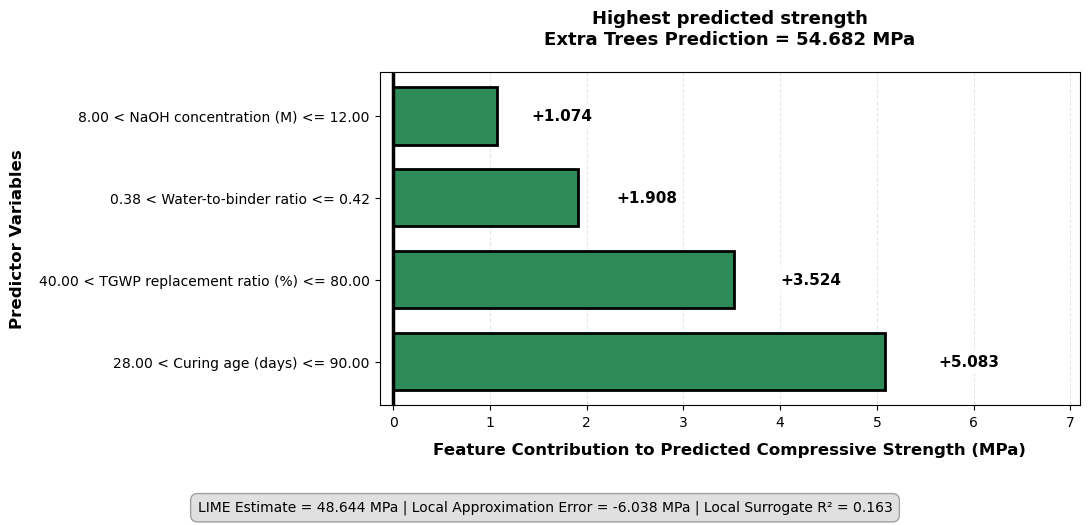

Saved contribution plot: C:\Users\suhai\Desktop\LIME\LIME_Contribution_Lowest_predicted_strength.png


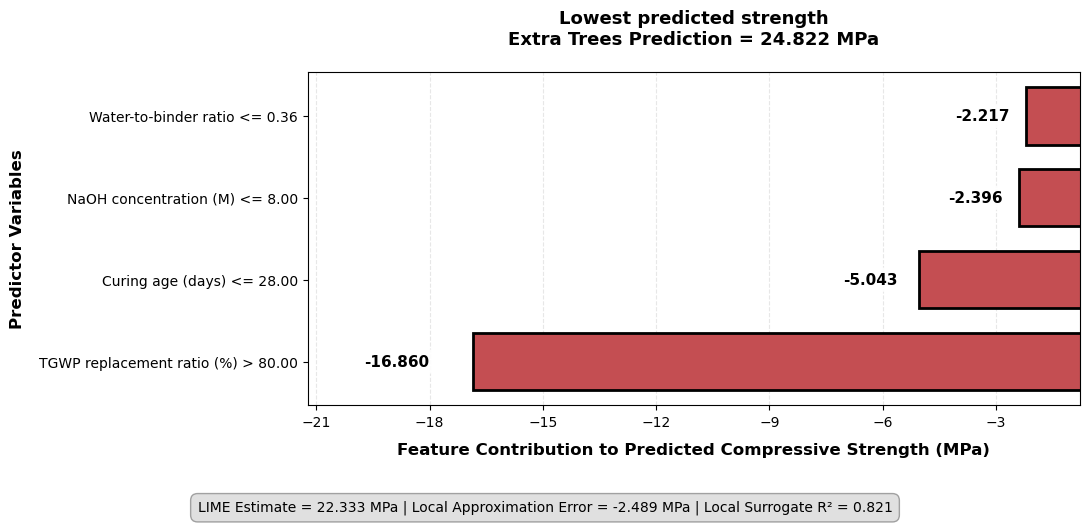

Saved contribution plot: C:\Users\suhai\Desktop\LIME\LIME_Contribution_Random_test_observation.png


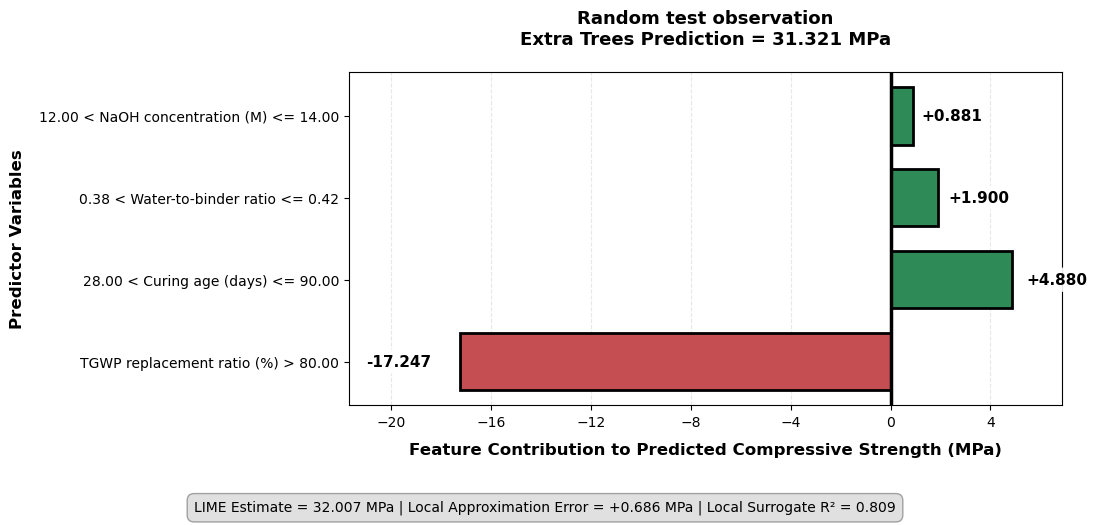


CREATING WATERFALL PLOTS
Saved waterfall plot: C:\Users\suhai\Desktop\LIME\LIME_Waterfall_Highest_predicted_strength.png


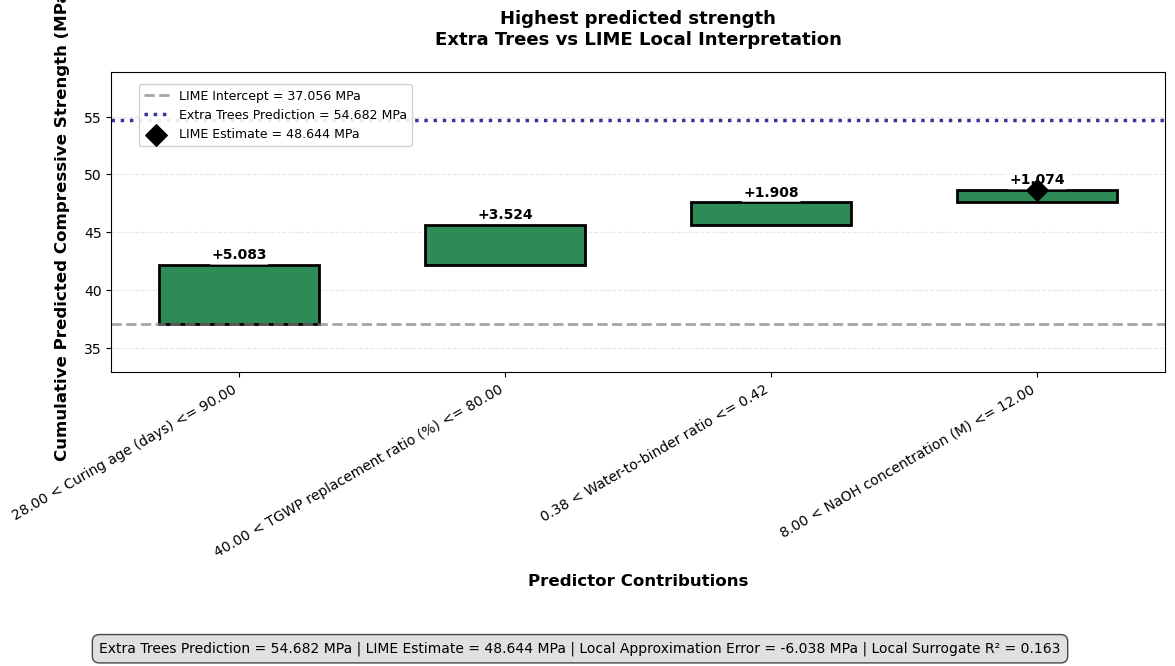

Saved waterfall plot: C:\Users\suhai\Desktop\LIME\LIME_Waterfall_Lowest_predicted_strength.png


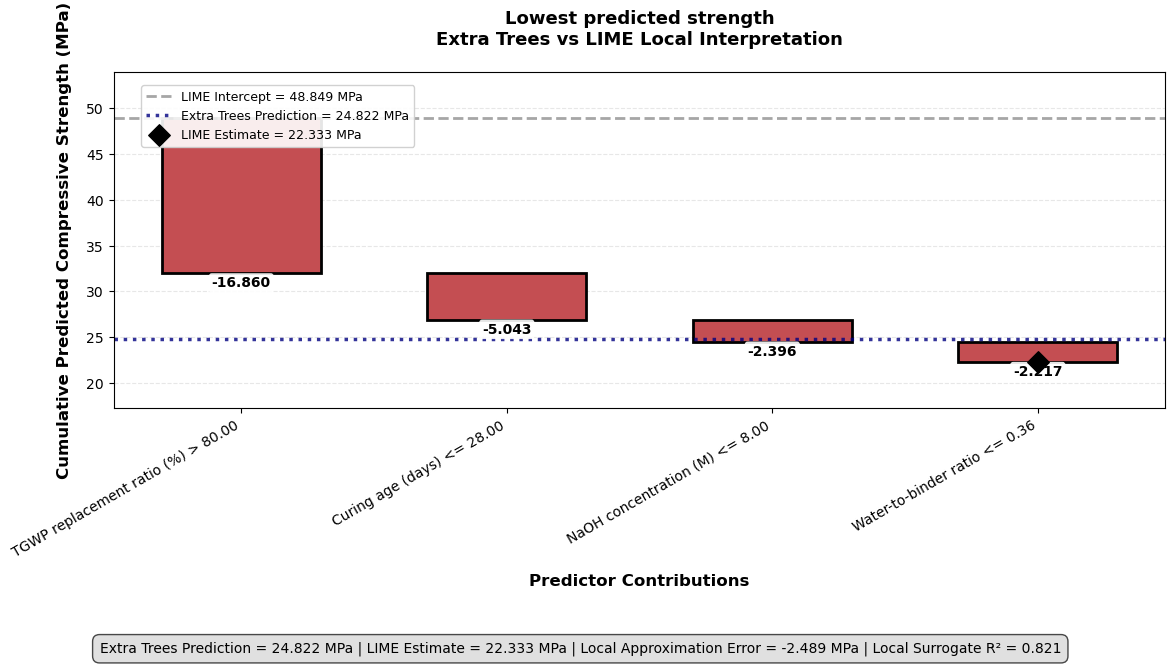

Saved waterfall plot: C:\Users\suhai\Desktop\LIME\LIME_Waterfall_Random_test_observation.png


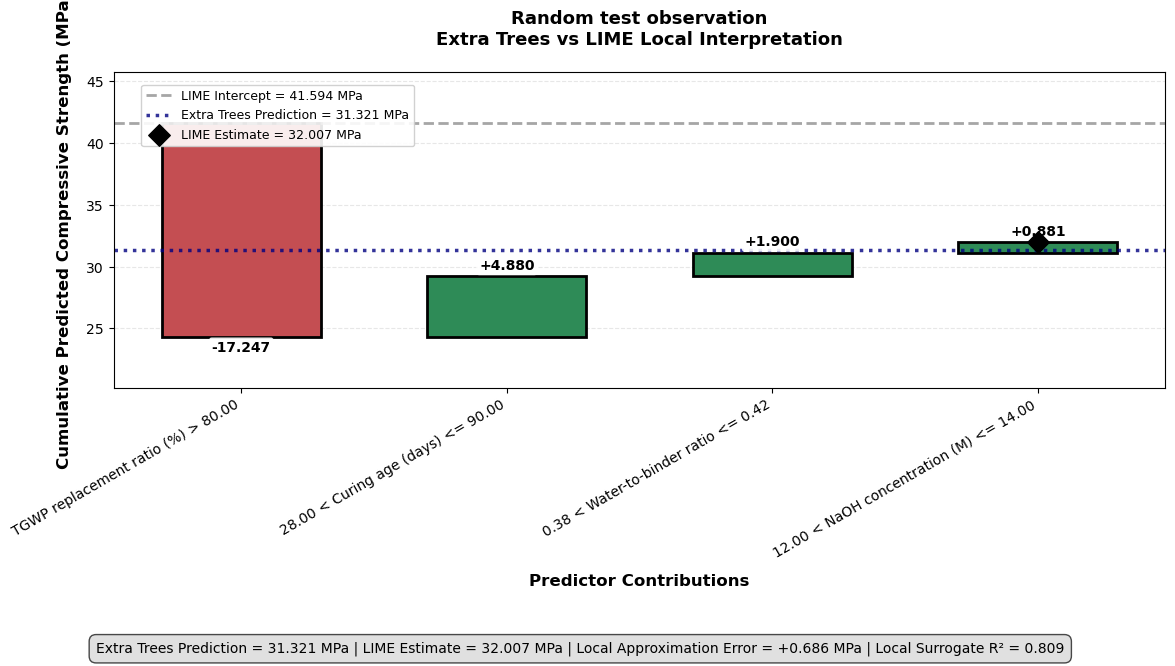


FINAL LIME IDENTITY VERIFICATION

Highest predicted strength:
  Intercept + contributions = 48.6444526246
  LIME local prediction = 48.6444526246
  Identity check (should be True): True
  Identity difference: +0.0000000000

Lowest predicted strength:
  Intercept + contributions = 22.3329873357
  LIME local prediction = 22.3329873357
  Identity check (should be True): True
  Identity difference: +0.0000000000

Random test observation:
  Intercept + contributions = 32.0074749230
  LIME local prediction = 32.0074749230
  Identity check (should be True): True
  Identity difference: -0.0000000000

EXPORTING RESULTS
Detailed results saved to: C:\Users\suhai\Desktop\LIME\LIME_Three_Selected_Observations.csv

LIME ANALYSIS COMPLETED SUCCESSFULLY

All results saved in: C:\Users\suhai\Desktop\LIME

Generated LIME explanations for three observations:

Highest predicted strength:
  Test position: 5
  Extra Trees prediction: 54.682 MPa
  LIME estimate: 48.644 MPa
  Local approximation error: -6.03

In [3]:
# =============================================================================
# COMPLETE CODE: EXTRA TREES MODEL + LIME EXPLANATIONS
# FIXED VERSION - NO TEXT OVERLAPPING IN ANY PLOTS
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from lime.lime_tabular import LimeTabularExplainer

# =============================================================================
# 1. SET SEED FOR REPRODUCIBILITY
# =============================================================================
np.random.seed(42)

# =============================================================================
# 2. SET SAVE DIRECTORY
# =============================================================================
SAVE_DIR = r"C:\Users\suhai\Desktop\LIME"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")

# =============================================================================
# 3. LOAD DATA
# =============================================================================
print("\n" + "=" * 90)
print("LOADING DATA")
print("=" * 90)

# Load your data
data_path = r"D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Data\Data.csv"
data = pd.read_csv(data_path)

print(f"Data loaded successfully!")
print(f"Dataset shape: {data.shape}")
print(f"\nActual column names in the CSV file:")
for i, col in enumerate(data.columns, 1):
    print(f"  {i}. '{col}'")

print("\nFirst 5 rows:")
print(data.head())

# =============================================================================
# 4. DEFINE FEATURES AND TARGET (WITH FLEXIBLE COLUMN NAME MATCHING)
# =============================================================================
print("\n" + "=" * 90)
print("PREPARING FEATURES AND TARGET")
print("=" * 90)

# Define the feature names we want (as per reviewer)
FEATURE_NAMES_TARGET = [
    "TGWP replacement ratio (%)",
    "Water-to-binder ratio",
    "NaOH concentration (M)",
    "Curing age (days)"
]

TARGET = "Compressive strength (Mpa)"

# Try to find matching columns in the data
column_mapping = {}

for expected_feature in FEATURE_NAMES_TARGET:
    found = False
    for actual_col in data.columns:
        if actual_col.strip().lower() == expected_feature.strip().lower():
            column_mapping[expected_feature] = actual_col
            found = True
            break
        elif expected_feature.strip().lower() in actual_col.strip().lower():
            column_mapping[expected_feature] = actual_col
            found = True
            break
        elif actual_col.strip().lower() in expected_feature.strip().lower():
            column_mapping[expected_feature] = actual_col
            found = True
            break
    
    if not found:
        print(f"WARNING: Could not find a match for '{expected_feature}'")
        for actual_col in data.columns:
            if any(word in actual_col.lower() for word in expected_feature.lower().split()):
                print(f"  Possible match: '{actual_col}'")
                column_mapping[expected_feature] = actual_col
                found = True
                break

# Check for target column
target_found = False
for actual_col in data.columns:
    if "compressive" in actual_col.lower() and "strength" in actual_col.lower():
        target_column = actual_col
        target_found = True
        break
    elif "strength" in actual_col.lower():
        target_column = actual_col
        target_found = True
        break

if not target_found:
    print(f"WARNING: Could not find target column 'Compressive strength (Mpa)'")
    target_column = data.columns[-1]
    print(f"  Using last column: '{target_column}' as target")
else:
    print(f"Target column found: '{target_column}'")

print("\nColumn mapping:")
for expected, actual in column_mapping.items():
    print(f"  '{expected}' -> '{actual}'")

# Extract features and target
X = pd.DataFrame()
for expected_feature in FEATURE_NAMES_TARGET:
    if expected_feature in column_mapping:
        X[expected_feature] = data[column_mapping[expected_feature]]
    else:
        raise KeyError(f"Feature '{expected_feature}' not found in data")

y = data[target_column]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFeature statistics:")
print(X.describe())
print(f"\nTarget statistics:")
print(y.describe())

# =============================================================================
# 5. SPLIT DATA INTO TRAIN AND TEST SETS
# =============================================================================
print("\n" + "=" * 90)
print("SPLITTING DATA INTO TRAIN AND TEST SETS")
print("=" * 90)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =============================================================================
# 6. TRAIN EXTRA TREES MODEL
# =============================================================================
print("\n" + "=" * 90)
print("TRAINING EXTRA TREES MODEL")
print("=" * 90)

extra_trees = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train, y_train)

print("Extra Trees model trained successfully!")

# =============================================================================
# 7. EVALUATE MODEL PERFORMANCE
# =============================================================================
print("\n" + "=" * 90)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 90)

train_score = extra_trees.score(X_train, y_train)
print(f"Training R² score: {train_score:.4f}")

test_score = extra_trees.score(X_test, y_test)
print(f"Test R² score: {test_score:.4f}")

feature_importance = pd.DataFrame({
    'Feature': FEATURE_NAMES_TARGET,
    'Importance': extra_trees.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature importance:")
print(feature_importance)

# =============================================================================
# 8. GENERATE TEST PREDICTIONS AND SELECT OBSERVATIONS
# =============================================================================
print("\n" + "=" * 90)
print("SELECTING THREE TEST OBSERVATIONS")
print("=" * 90)

test_predictions = extra_trees.predict(X_test)

highest_pos = np.argmax(test_predictions)
lowest_pos = np.argmin(test_predictions)

rng = np.random.default_rng(42)
random_pos = rng.integers(0, len(X_test))

selected = {
    "Highest predicted strength": int(highest_pos),
    "Lowest predicted strength": int(lowest_pos),
    "Random test observation": int(random_pos)
}

print("\nSelected observations:")
for title, pos in selected.items():
    print(f"\n{title}:")
    print(f"  Test position: {pos}")
    print(f"  Extra Trees prediction: {test_predictions[pos]:.6f} MPa")
    print(f"  Actual value: {y_test.iloc[pos]:.6f} MPa")
    print(f"  Features:")
    for i, feature in enumerate(FEATURE_NAMES_TARGET):
        print(f"    {feature}: {X_test.iloc[pos, i]:.6f}")

# =============================================================================
# 9. CREATE LIME EXPLAINER
# =============================================================================
print("\n" + "=" * 90)
print("CREATING LIME EXPLAINER")
print("=" * 90)

X_train_lime = np.asarray(X_train, dtype=float)
X_test_lime = np.asarray(X_test, dtype=float)

feature_names = FEATURE_NAMES_TARGET.copy()

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode="regression",
    discretize_continuous=True,
    kernel_width=1.50,
    random_state=42
)

print("LIME explainer created successfully!")
print(f"LIME kernel width: 1.50")
print(f"LIME perturbation samples per explanation: 5000")
print(f"LIME discretize_continuous: True")
print(f"Using {len(feature_names)} features")

# =============================================================================
# 10. GENERATE LIME EXPLANATIONS
# =============================================================================
print("\n" + "=" * 90)
print("GENERATING LIME EXPLANATIONS")
print("=" * 90)

results = {}

for title, pos in selected.items():
    print(f"\n{'='*90}")
    print(f"PROCESSING: {title}")
    print(f"{'='*90}")
    
    instance = np.asarray(X_test.iloc[pos], dtype=float)
    model_prediction = float(test_predictions[pos])
    
    explanation = explainer.explain_instance(
        data_row=instance,
        predict_fn=extra_trees.predict,
        num_features=4,
        num_samples=5000
    )
    
    # Extract information safely
    if isinstance(explanation.intercept, dict):
        intercept = float(list(explanation.intercept.values())[0])
    elif isinstance(explanation.intercept, (list, np.ndarray)):
        intercept = float(np.ravel(explanation.intercept)[0])
    else:
        intercept = float(explanation.intercept)
    
    if isinstance(explanation.local_pred, dict):
        lime_prediction = float(list(explanation.local_pred.values())[0])
    elif isinstance(explanation.local_pred, (list, np.ndarray)):
        lime_prediction = float(np.ravel(explanation.local_pred)[0])
    else:
        lime_prediction = float(explanation.local_pred)
    
    contributions = explanation.as_list()
    approximation_error = lime_prediction - model_prediction
    
    results[title] = {
        "input_values": instance,
        "model_prediction": model_prediction,
        "intercept": intercept,
        "contributions": contributions,
        "lime_prediction": lime_prediction,
        "approximation_error": approximation_error,
        "r2_local": explanation.score,
        "position": pos
    }
    
    print(f"\n{title}")
    print("Inputs:", dict(zip(feature_names, instance)))
    print("Extra Trees prediction:", model_prediction)
    print("LIME intercept:", intercept)
    print("Contributions:", contributions)
    print("Intercept + contributions:",
          intercept + sum(v for _, v in contributions))
    print("LIME local prediction:", lime_prediction)
    print("Approximation error:", approximation_error)
    print("Local surrogate R²:", explanation.score)
    
    identity_check = np.isclose(
        intercept + sum(v for _, v in contributions),
        lime_prediction,
        atol=1e-6
    )
    print(f"Identity check (should be True): {identity_check}")

# =============================================================================
# 11. HORIZONTAL CONTRIBUTION PLOTS (FIXED - NO OVERLAPPING)
# =============================================================================
print("\n" + "=" * 90)
print("CREATING HORIZONTAL CONTRIBUTION PLOTS")
print("=" * 90)

for title, result in results.items():
    labels = [x[0] for x in result["contributions"]]
    values = np.array([x[1] for x in result["contributions"]])
    
    colors = np.where(values >= 0, "#2E8B57", "#C44E52")
    
    fig, ax = plt.subplots(figsize=(11, 5.5))
    
    bars = ax.barh(labels, values, color=colors, edgecolor='black', linewidth=2, height=0.7)
    
    ax.axvline(0, color="black", linewidth=2.5)
    
    # Calculate x-axis limits for text positioning
    x_min = min(values) - (abs(min(values)) * 0.2) - 1
    x_max = max(values) + (abs(max(values)) * 0.2) + 1
    ax.set_xlim([x_min, x_max])
    
    # Add value labels with white background
    for i, (bar, value) in enumerate(zip(bars, values)):
        if value >= 0:
            x_pos = value + (abs(value) * 0.05) + 0.3
            ha = 'left'
        else:
            x_pos = value - (abs(value) * 0.05) - 0.3
            ha = 'right'
        
        ax.text(
            x_pos, 
            bar.get_y() + bar.get_height()/2, 
            f'{value:+.3f}', 
            va='center', 
            ha=ha, 
            fontsize=11, 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor='none')
        )
    
    ax.set_xlabel("Feature Contribution to Predicted Compressive Strength (MPa)", 
                  fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel("Predictor Variables", fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title(f"{title}\nExtra Trees Prediction = {result['model_prediction']:.3f} MPa", 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    
    footnote = (f"LIME Estimate = {result['lime_prediction']:.3f} MPa | "
                f"Local Approximation Error = {result['approximation_error']:+.3f} MPa | "
                f"Local Surrogate R² = {result['r2_local']:.3f}")
    
    plt.figtext(0.5, 0.01, footnote, ha="center", fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.7, edgecolor='gray'))
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    
    safe_title = title.replace(" ", "_")
    contribution_path = os.path.join(SAVE_DIR, f"LIME_Contribution_{safe_title}.png")
    fig.savefig(contribution_path, dpi=600, bbox_inches="tight")
    print(f"Saved contribution plot: {contribution_path}")
    
    plt.show()
    plt.close(fig)

# =============================================================================
# 12. WATERFALL PLOTS (FIXED - NO OVERLAPPING)
# =============================================================================
print("\n" + "=" * 90)
print("CREATING WATERFALL PLOTS")
print("=" * 90)

for title, result in results.items():
    labels = [x[0] for x in result["contributions"]]
    values = np.array([x[1] for x in result["contributions"]])
    
    starting_points = (
        result["intercept"]
        + np.concatenate(([0], np.cumsum(values[:-1])))
    )
    
    colors = np.where(values >= 0, "#2E8B57", "#C44E52")
    
    # Calculate y-axis range
    all_points = []
    for start, value in zip(starting_points, values):
        all_points.append(start)
        all_points.append(start + value)
    all_points.append(result["intercept"])
    all_points.append(result["model_prediction"])
    y_min = min(all_points) - 2
    y_max = max(all_points) + 2
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot bars
    for i, (start, value, color) in enumerate(
        zip(starting_points, values, colors)
    ):
        ax.bar(
            i,
            value,
            bottom=start,
            color=color,
            edgecolor="black",
            linewidth=2,
            width=0.6
        )
        
        # Position text with background
        text_y = start + value
        if value >= 0:
            va = 'bottom'
            offset = 0.3
        else:
            va = 'top'
            offset = -0.3
        
        ax.text(
            i,
            text_y + offset,
            f"{value:+.3f}",
            ha="center",
            va=va,
            fontsize=10,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9, edgecolor='none')
        )
    
    endpoint = result["intercept"] + values.sum()
    
    # Reference lines
    ax.axhline(
        result["intercept"],
        color="grey",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label=f"LIME Intercept = {result['intercept']:.3f} MPa"
    )
    
    ax.axhline(
        result["model_prediction"],
        color="navy",
        linestyle=":",
        linewidth=2.5,
        alpha=0.8,
        label=f"Extra Trees Prediction = {result['model_prediction']:.3f} MPa"
    )
    
    # Endpoint marker
    ax.scatter(
        len(values) - 1,
        endpoint,
        color="black",
        s=120,
        zorder=5,
        marker='D',
        label=f"LIME Estimate = {endpoint:.3f} MPa"
    )
    
    # Formatting
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
    ax.set_xlabel("Predictor Contributions", fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel("Cumulative Predicted Compressive Strength (MPa)", 
                  fontsize=12, fontweight='bold', labelpad=10)
    
    y_padding = abs(y_max - y_min) * 0.1
    ax.set_ylim([y_min - y_padding, y_max + y_padding])
    
    ax.set_title(f"{title}\nExtra Trees vs LIME Local Interpretation", 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    ax.legend(loc="upper left", frameon=True, fontsize=9, framealpha=0.9, 
              bbox_to_anchor=(0.02, 0.98))
    
    footnote = (f"Extra Trees Prediction = {result['model_prediction']:.3f} MPa | "
                f"LIME Estimate = {result['lime_prediction']:.3f} MPa | "
                f"Local Approximation Error = {result['approximation_error']:+.3f} MPa | "
                f"Local Surrogate R² = {result['r2_local']:.3f}")
    
    plt.figtext(0.5, 0.01, footnote, ha="center", fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    
    safe_title = title.replace(" ", "_")
    waterfall_path = os.path.join(SAVE_DIR, f"LIME_Waterfall_{safe_title}.png")
    fig.savefig(waterfall_path, dpi=600, bbox_inches="tight")
    print(f"Saved waterfall plot: {waterfall_path}")
    
    plt.show()
    plt.close(fig)

# =============================================================================
# 13. FINAL IDENTITY VERIFICATION
# =============================================================================
print("\n" + "=" * 90)
print("FINAL LIME IDENTITY VERIFICATION")
print("=" * 90)

for title, result in results.items():
    identity_value = (
        result["intercept"] +
        sum(v for _, v in result["contributions"])
    )
    
    identity_check = np.isclose(
        identity_value,
        result["lime_prediction"],
        atol=1e-6
    )
    
    print(f"\n{title}:")
    print(f"  Intercept + contributions = {identity_value:.10f}")
    print(f"  LIME local prediction = {result['lime_prediction']:.10f}")
    print(f"  Identity check (should be True): {identity_check}")
    print(f"  Identity difference: {identity_value - result['lime_prediction']:+.10f}")

# =============================================================================
# 14. EXPORT RESULTS TO CSV
# =============================================================================
print("\n" + "=" * 90)
print("EXPORTING RESULTS")
print("=" * 90)

detailed_rows = []
for title, result in results.items():
    row = {
        "Observation": title,
        "Test_Position": result["position"],
        "Extra_Trees_Prediction_MPa": result["model_prediction"],
        "LIME_Intercept_MPa": result["intercept"],
        "LIME_Estimate_MPa": result["lime_prediction"],
        "Approximation_Error_MPa": result["approximation_error"],
        "Local_Surrogate_R2": result["r2_local"],
    }
    
    for feature, value in zip(FEATURE_NAMES_TARGET, result["input_values"]):
        safe_feature = feature.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "").replace("%", "percent")
        row[f"Input_{safe_feature}"] = value
    
    for feature, contribution in result["contributions"]:
        row[f"LIME_Contribution_{feature}"] = contribution
    
    detailed_rows.append(row)

detailed_df = pd.DataFrame(detailed_rows)
detailed_path = os.path.join(SAVE_DIR, "LIME_Three_Selected_Observations.csv")
detailed_df.to_csv(detailed_path, index=False)
print(f"Detailed results saved to: {detailed_path}")

# =============================================================================
# 15. FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 90)
print("LIME ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 90)

print(f"\nAll results saved in: {SAVE_DIR}")
print("\nGenerated LIME explanations for three observations:")

for title, result in results.items():
    print(f"\n{title}:")
    print(f"  Test position: {result['position']}")
    print(f"  Extra Trees prediction: {result['model_prediction']:.3f} MPa")
    print(f"  LIME estimate: {result['lime_prediction']:.3f} MPa")
    print(f"  Local approximation error: {result['approximation_error']:+.3f} MPa")
    print(f"  Local surrogate R²: {result['r2_local']:.3f}")
    
    identity_value = result["intercept"] + sum(v for _, v in result["contributions"])
    identity_check = np.isclose(identity_value, result["lime_prediction"], atol=1e-6)
    print(f"  Identity check: {identity_check}")

print("\n" + "=" * 90)
print("END OF LIME ANALYSIS")
print("=" * 90)

print("\n" + "=" * 90)
print("FILES CREATED")
print("=" * 90)
files_created = os.listdir(SAVE_DIR)
for file in files_created:
    file_path = os.path.join(SAVE_DIR, file)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f"  - {file} ({size:.1f} KB)")